# Deep Hedging with Hidden Volatility Regimes
## 2-State Markov-Switching Volatility, No Transaction Costs

**Based on:** Buehler, Gonon, Teichmann, Wood, Mohan & Kochems (2019)  
*"Deep Hedging: Hedging Derivatives Under Generic Market Frictions Using Reinforcement Learning"*

---

This notebook extends the BS deep hedging experiment in `deep_hedging_section42.ipynb` by replacing the constant-volatility GBM with a **2-state Markov-switching volatility** model. The central question: can the networks infer which volatility regime the market is in, purely from the observed price process? The regime is never given to the networks as an input.

| | `deep_hedging_section42.ipynb` (BS baseline) | This notebook |
|---|---|---|
| Market model | Constant-vol GBM, $\sigma = 0.20$ | 2-state Markov-switching GBM |
| Volatility | $\sigma = 0.20$ | $\sigma_L = 0.20$, $\sigma_H = 0.70$ (hidden) |
| Model benchmark | BS delta $N(d_1)$ | Markov delta (oracle: knows regime) |
| Network inputs | No regime information provided | No regime information provided |
| Key question | Can networks recover BS delta? | Can networks infer the hidden regime? |

All network architectures (Simple and Recurrent MLP), the CVaR(50%) objective with Rockafellar–Uryasev dual formulation, the Adam optimiser, and the batch size are unchanged from `deep_hedging_section42.ipynb`. The occupation-time pricing machinery (Bessel-series densities, LUT precomputation via vectorised `trapezoid`) follows *Markov_Option_Prices.ipynb*.

## 0. Imports and Global Parameters

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.integrate import quad, trapezoid
from scipy.interpolate import interp1d
from scipy.linalg import expm
import math
import time
import warnings
warnings.filterwarnings('ignore')

# ── Market parameters ──────────────────────────────────────────────────────
S0      = 100.0   # initial stock price
K       = 100.0   # strike (ATM call)
RATE    = 0.0     # risk-free rate
SIGMA_L = 0.20    # low-volatility state  (consistent with lecture notebooks)
SIGMA_H = 0.70    # high-volatility state
N_STEPS = 30      # rebalancing steps (30 trading days)
T       = N_STEPS / 252.0   # option maturity in years
DT      = T / N_STEPS       # one day = 1/252 yr

# ── Markov chain rates (per year) ───────────────────────────────────────────
ALPHA_RATE = 10.0   # L → H switching rate  (mean time in L ≈ 252/10 = 25 days)
BETA_RATE  = 20.0   # H → L switching rate  (mean time in H ≈ 252/20 = 13 days)
PI_L = BETA_RATE  / (ALPHA_RATE + BETA_RATE)   # stationary prob of L state = 2/3
PI_H = ALPHA_RATE / (ALPHA_RATE + BETA_RATE)   # stationary prob of H state = 1/3

# ── Learning parameters (unchanged from BS notebook) ──────────────────────
CVaR_ALPHA = 0.50   # CVaR level: 50%  (note: distinct from ALPHA_RATE above)
N_TRAIN    = 500_000
N_TEST     = 100_000
BATCH      = 256
LR         = 0.005
N_ITER     = 100_000
HIDDEN     = 15

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'S0={S0}, K={K}, r={RATE}')
print(f'\u03c3_L={SIGMA_L}, \u03c3_H={SIGMA_H}')
print(f'\u03b1={ALPHA_RATE}/yr (L\u2192H),  \u03b2={BETA_RATE}/yr (H\u2192L)')
print(f'Stationary distribution:  \u03c0_L = {PI_L:.4f},  \u03c0_H = {PI_H:.4f}')
print(f'Mean time in L: {252/ALPHA_RATE:.0f} days,  Mean time in H: {252/BETA_RATE:.0f} days')
print(f'T = {N_STEPS} trading days ({T:.4f} yr),  \u0394t = 1/252 yr')

Device : cpu
S0=100.0, K=100.0, r=0.0
σ_L=0.2, σ_H=0.7
α=10.0/yr (L→H),  β=20.0/yr (H→L)
Stationary distribution:  π_L = 0.6667,  π_H = 0.3333
Mean time in L: 25 days,  Mean time in H: 13 days
T = 30 trading days (0.1190 yr),  Δt = 1/252 yr


## 1. The 2-State Markov-Switching Market

### 1.1 Continuous-time Markov chain

The volatility alternates between a low state $\sigma_L$ and a high state $\sigma_H$ via a continuous-time Markov chain with **generator matrix**

$$Q = \begin{pmatrix}-\alpha & \alpha \\ \beta & -\beta\end{pmatrix}$$

where $\alpha$ is the L$\to$H switching rate and $\beta$ is the H$\to$L rate. The exact one-step transition matrix is $P(\Delta t) = e^{Q\,\Delta t}$, computed via `scipy.linalg.expm` exactly as in *Volatility_Modeling.ipynb* (no Euler approximation).

The **stationary distribution** is

$$\pi_L = \frac{\beta}{\alpha+\beta} = \tfrac{2}{3}, \qquad \pi_H = \frac{\alpha}{\alpha+\beta} = \tfrac{1}{3}.$$

Each path's starting regime is drawn from this distribution, so the training and test populations are stationary.

In [2]:
# ── Generator and exact transition matrix (Volatility_Modeling.ipynb pattern) ──────
gen_matrix = np.array([[-ALPHA_RATE, ALPHA_RATE],
                        [BETA_RATE,  -BETA_RATE]])
P_step = expm(gen_matrix * DT)   # exact, no approximation error

print('Generator Q:')
print(gen_matrix)
print(f'\nTransition matrix P(\u0394t) = exp(Q\u00b7\u0394t)  [\u0394t = 1/252 yr]:')
print(P_step)
print(f'\n  P(stay in L) = {P_step[0,0]:.6f},   P(L\u2192H per day) = {P_step[0,1]:.6f}')
print(f'  P(H\u2192L per day) = {P_step[1,0]:.6f},  P(stay in H) = {P_step[1,1]:.6f}')
print(f'\n  Row sums (must be 1): {P_step.sum(axis=1)}')
print(f'  Expected regime switches in {N_STEPS}-day window (from L): ≈{ALPHA_RATE*T:.2f} L\u2192H,  {BETA_RATE*T:.2f} H\u2192L')

Generator Q:
[[-10.  10.]
 [ 20. -20.]]

Transition matrix P(Δt) = exp(Q·Δt)  [Δt = 1/252 yr]:
[[0.96258851 0.03741149]
 [0.07482298 0.92517702]]

  P(stay in L) = 0.962589,   P(L→H per day) = 0.037411
  P(H→L per day) = 0.074823,  P(stay in H) = 0.925177

  Row sums (must be 1): [1. 1.]
  Expected regime switches in 30-day window (from L): ≈1.19 L→H,  2.38 H→L


### 1.2 Path Simulation

Under the risk-neutral measure $\mathbb{Q}$, the stock follows GBM with the current regime's volatility:

$$S_{t+1} = S_t \exp\!\Bigl[(r - \tfrac{1}{2}\sigma_{R_t}^2)\Delta t + \sigma_{R_t}\sqrt{\Delta t}\,Z_t\Bigr], \quad Z_t \overset{\text{i.i.d.}}{\sim}\mathcal{N}(0,1)$$

where $R_t \in \{L, H\}$ is the regime at step $t$, simulated from the exact Markov transition matrix as in *Volatility_Modeling.ipynb*.

The simulator returns both the stock price tensor and the regime-state array. The networks receive only the price tensor; the state array is used exclusively for the model benchmark and diagnostic plots.

In [3]:
def simulate_paths_markov(S0, r, sigma_L, sigma_H, P, pi_H,
                          T, N_steps, N_paths, seed=None):
    """
    Simulate GBM paths under 2-state Markov-switching volatility.

    Parameters
    ----------
    P    : (2,2) exact one-step transition matrix from expm(Q * dt)
    pi_H : probability of starting in the high-volatility state

    Returns
    -------
    S      : torch float32 tensor (N_paths, N_steps+1) on DEVICE  -- visible to networks
    states : numpy int8 array   (N_paths, N_steps)   0=L, 1=H   -- hidden from networks
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed + 999)

    dt = T / N_steps

    # ── Simulate regime sequence (Volatility_Modeling.ipynb pattern) ──────────────
    states = np.zeros((N_paths, N_steps), dtype=np.int8)
    states[:, 0] = (np.random.random(N_paths) < pi_H).astype(np.int8)  # stationary init

    uniforms = np.random.random((N_paths, N_steps))
    for i in range(1, N_steps):
        prev = states[:, i - 1]
        U    = uniforms[:, i - 1]
        in_L = prev == 0
        in_H = prev == 1
        states[in_L, i] = np.where(U[in_L] < P[0, 0], 0, 1)
        states[in_H, i] = np.where(U[in_H] < P[1, 1], 1, 0)

    # ── Simulate log-returns with regime-dependent volatility ────────────────────
    sigmas = np.where(states == 0, sigma_L, sigma_H)  # (N, T)
    Z      = np.random.randn(N_paths, N_steps)
    inc    = (r - 0.5 * sigmas**2) * dt + sigmas * np.sqrt(dt) * Z
    log_S  = np.cumsum(inc, axis=1)   # cumulative log-returns from S0
    S_path = np.exp(np.log(S0) + log_S)                         # (N, T)
    S_full = np.concatenate([np.full((N_paths, 1), S0), S_path], axis=1)  # (N, T+1)
    S_t    = torch.tensor(S_full.astype(np.float32), device=DEVICE)
    return S_t, states


# ── Quick sanity check: regime fractions should match stationary distribution ──────
S_chk, st_chk = simulate_paths_markov(S0, RATE, SIGMA_L, SIGMA_H, P_step, PI_H,
                                       T, N_STEPS, 200_000, seed=0)
frac_H_chk = st_chk.mean()
pay_chk    = torch.relu(S_chk[:, -1] - K).mean().item()
print(f'Fraction of steps in H-state: {frac_H_chk:.4f}  (stationary \u03c0_H = {PI_H:.4f})')
print(f'Simulated mean payoff: {pay_chk:.4f}')

Fraction of steps in H-state: 0.3331  (stationary π_H = 0.3333)
Simulated mean payoff: 5.6063


### 1.3 Markov Option Price and Model Benchmark Delta

Following *Markov_Option_Prices.ipynb*, the call price is obtained by averaging Black-Scholes prices over the distribution of time $U_H$ spent in the high-volatility state.

Given $U_H = u$, the effective volatility is
$$\sigma_{\mathrm{eff}}(u) = \sqrt{\frac{\sigma_L^2(\tau-u) + \sigma_H^2\,u}{\tau}}.$$

**Starting in L:** $\displaystyle\mathcal{C}_{M,L} = e^{-\alpha\tau}\mathcal{C}_{\mathrm{BS}}(\sigma_L) + \int_0^\tau \mathcal{C}_{\mathrm{BS}}(\sigma_{\mathrm{eff}}(u))\,f_L(u)\,du$

**Starting in H:** $\displaystyle\mathcal{C}_{M,H} = e^{-\beta\tau}\mathcal{C}_{\mathrm{BS}}(\sigma_H) + \int_0^\tau \mathcal{C}_{\mathrm{BS}}(\sigma_{\mathrm{eff}}(u))\,f_H(u)\,du$

The occupation-time densities involve Bessel-type series:
$$S_1(x) = \sum_{k=0}^\infty \frac{x^k}{(k!)^2}, \qquad S_2(x) = \sum_{k=0}^\infty \frac{x^k}{k!\,(k+1)!}$$

These are precomputed on a fine grid and accessed via `interp1d`, exactly as in *Markov_Option_Prices.ipynb*. The model price at the stationary initial distribution is $\mathcal{C}_M = \pi_L\,\mathcal{C}_{M,L} + \pi_H\,\mathcal{C}_{M,H}$.

The **Markov delta** replaces $\mathcal{C}_{\mathrm{BS}}$ with $\Delta_{\mathrm{BS}} = N(d_1)$. For efficient path-level evaluation it is precomputed on a grid of spot prices at each of the 30 time steps using vectorised `trapezoid` integration which is the vectorisable alternative to `scipy.integrate.quad` demonstrated in *Volatility_Modeling.ipynb*.

In [4]:
# ── S₁ and S₂ series (precomputed and interpolated as in Markov_Option_Prices.ipynb) ──
# With our parameters, x = αβu(τ−u) ≤ αβ(τ/2)² ≈ 0.71, so x_max = 5 is ample.
_x_grid  = np.linspace(0, 5, 200_000)
_ints    = np.arange(40)
_facts   = np.array([math.factorial(k)   for k in _ints])
_facts1  = np.array([math.factorial(k+1) for k in _ints])

_s1_vals = np.sum(_x_grid[:, None]**_ints / _facts**2,          axis=1)
_s2_vals = np.sum(_x_grid[:, None]**_ints / (_facts * _facts1), axis=1)

_s1 = interp1d(_x_grid, _s1_vals, bounds_error=False,
               fill_value=(_s1_vals[0], _s1_vals[-1]))
_s2 = interp1d(_x_grid, _s2_vals, bounds_error=False,
               fill_value=(_s2_vals[0], _s2_vals[-1]))


def sigma_eff(sigma_L, sigma_H, tau, u):
    """Effective volatility given u time spent in high-vol state."""
    return np.sqrt((sigma_L**2 * (tau - u) + sigma_H**2 * u) / tau)


def density_L(u, alpha_r, beta_r, tau):
    """Occupation-time density f_L(u): stock starts in low-vol state."""
    x = alpha_r * beta_r * u * (tau - u)
    return (np.exp(-alpha_r*(tau - u) - beta_r*u) *
            (alpha_r * _s1(x) + alpha_r*beta_r*(tau - u) * _s2(x)))


def density_H(u, alpha_r, beta_r, tau):
    """Occupation-time density f_H(u): stock starts in high-vol state."""
    x = alpha_r * beta_r * u * (tau - u)
    return (np.exp(-beta_r*u - alpha_r*(tau - u)) *
            (beta_r * _s1(x) + alpha_r*beta_r*u * _s2(x)))


def bs_call_price(S, K, r, sigma, tau):
    """Black-Scholes European call price (scalar)."""
    if tau < 1e-12:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return float(S * norm.cdf(d1) - K * np.exp(-r*tau) * norm.cdf(d2))


def markov_call_low(S0, K, r, sigma_L, sigma_H, tau, alpha_r, beta_r):
    """Markov call price starting in the low-vol state (uses quad for one-time use)."""
    atom = np.exp(-alpha_r*tau) * bs_call_price(S0, K, r, sigma_L, tau)
    def integrand(u):
        return (bs_call_price(S0, K, r, sigma_eff(sigma_L, sigma_H, tau, u), tau) *
                density_L(u, alpha_r, beta_r, tau))
    val, _ = quad(integrand, 0, tau)
    return atom + val


def markov_call_high(S0, K, r, sigma_L, sigma_H, tau, alpha_r, beta_r):
    """Markov call price starting in the high-vol state."""
    atom = np.exp(-beta_r*tau) * bs_call_price(S0, K, r, sigma_H, tau)
    def integrand(u):
        return (bs_call_price(S0, K, r, sigma_eff(sigma_L, sigma_H, tau, u), tau) *
                density_H(u, alpha_r, beta_r, tau))
    val, _ = quad(integrand, 0, tau)
    return atom + val

In [5]:
# ── Markov model price at stationary initial distribution ────────────────────────
C_ML = markov_call_low( S0, K, RATE, SIGMA_L, SIGMA_H, T, ALPHA_RATE, BETA_RATE)
C_MH = markov_call_high(S0, K, RATE, SIGMA_L, SIGMA_H, T, ALPHA_RATE, BETA_RATE)
model_price = PI_L * C_ML + PI_H * C_MH

bs_price_L = bs_call_price(S0, K, RATE, SIGMA_L, T)
bs_price_H = bs_call_price(S0, K, RATE, SIGMA_H, T)

print(f'BS price  (\u03c3_L = {SIGMA_L}):                 {bs_price_L:.4f}')
print(f'Markov price  | starting in L state:     {C_ML:.4f}')
print(f'Markov price  | starting in H state:     {C_MH:.4f}')
print(f'BS price  (\u03c3_H = {SIGMA_H}):                 {bs_price_H:.4f}')
print(f'\nMarkov model price (stationary weights):  {model_price:.4f}')
print(f'  = {PI_L:.4f} \u00d7 {C_ML:.4f}  +  {PI_H:.4f} \u00d7 {C_MH:.4f}')
print(f'\nSanity check:  BS(\u03c3_L) < C_ML < model_price < C_MH < BS(\u03c3_H)?')
print(f'  {bs_price_L:.4f} < {C_ML:.4f} < {model_price:.4f} < {C_MH:.4f} < {bs_price_H:.4f}  ✔' if
      bs_price_L < C_ML < model_price < C_MH < bs_price_H else '  CHECK FAILED')

BS price  (σ_L = 0.2):                 2.7524
Markov price  | starting in L state:     4.9103
Markov price  | starting in H state:     6.9134
BS price  (σ_H = 0.7):                 9.6120

Markov model price (stationary weights):  5.5780
  = 0.6667 × 4.9103  +  0.3333 × 6.9134

Sanity check:  BS(σ_L) < C_ML < model_price < C_MH < BS(σ_H)?
  2.7524 < 4.9103 < 5.5780 < 6.9134 < 9.6120  ✔


### 1.4 Markov Delta Lookup Tables

For efficient path-level benchmark evaluation we precompute $\Delta_{M,L}(S,\tau_t)$ and $\Delta_{M,H}(S,\tau_t)$ on a fine grid of spot prices for each of the 30 time steps, using vectorised `trapezoid` integration. This gives 60 `interp1d` lookup functions that evaluate in microseconds during the hedge P&L computation.

In [6]:
# ── Precompute Markov delta on (S_grid, \u03c4_t, state) for all 30 time steps ─────────
N_U_GRID = 400          # integration grid points in u
S_LOOKUP = np.linspace(40.0, 220.0, 500)   # spot-price grid for interpolation

delta_lut_L = []   # delta_lut_L[t](S) = Markov delta, step t, L state
delta_lut_H = []   # delta_lut_H[t](S) = Markov delta, step t, H state

print('Precomputing Markov delta lookup tables ...', end=' ', flush=True)
t0_lut = time.time()

for t in range(N_STEPS):
    tau    = (N_STEPS - t) * DT
    u_grid = np.linspace(0, tau, N_U_GRID)         # (N_U,)

    # Vectorised density values at each u
    dens_L = density_L(u_grid, ALPHA_RATE, BETA_RATE, tau)  # (N_U,)
    dens_H = density_H(u_grid, ALPHA_RATE, BETA_RATE, tau)  # (N_U,)

    # sigma_eff at each u
    sig_u = sigma_eff(SIGMA_L, SIGMA_H, tau, u_grid)         # (N_U,)

    # N(d1) for each (S, u) pair — broadcast to (N_S, N_U)
    log_m = np.log(S_LOOKUP / K)[:, None]                   # (N_S, 1)
    d1    = (log_m + (RATE + 0.5*sig_u**2)*tau) / (sig_u * np.sqrt(tau))  # (N_S, N_U)
    Nd1   = norm.cdf(d1)                                     # (N_S, N_U)

    # Integrands: N(d1) \u00d7 density — vectorised trapezoid (Volatility_Modeling.ipynb technique)
    integ_L = Nd1 * dens_L[None, :]   # (N_S, N_U)
    integ_H = Nd1 * dens_H[None, :]   # (N_S, N_U)

    # Atom terms: prob of never switching \u00d7 BS delta at pure \u03c3_L or \u03c3_H
    d1_L = (np.log(S_LOOKUP/K) + (RATE + 0.5*SIGMA_L**2)*tau) / (SIGMA_L * np.sqrt(tau))
    d1_H = (np.log(S_LOOKUP/K) + (RATE + 0.5*SIGMA_H**2)*tau) / (SIGMA_H * np.sqrt(tau))

    delta_L = np.exp(-ALPHA_RATE*tau)*norm.cdf(d1_L) + trapezoid(integ_L, u_grid, axis=1)
    delta_H = np.exp(-BETA_RATE *tau)*norm.cdf(d1_H) + trapezoid(integ_H, u_grid, axis=1)

    delta_lut_L.append(interp1d(S_LOOKUP, delta_L, bounds_error=False, fill_value=(0.0, 1.0)))
    delta_lut_H.append(interp1d(S_LOOKUP, delta_H, bounds_error=False, fill_value=(0.0, 1.0)))

print(f'done in {time.time()-t0_lut:.1f}s')

# Quick verification: at t=0 (longest \u03c4), L-state delta should be between BS deltas
S_atm  = 100.0
d_ML_0 = float(delta_lut_L[0](S_atm))
d_MH_0 = float(delta_lut_H[0](S_atm))
bs_d_L = norm.cdf((np.log(S_atm/K) + 0.5*SIGMA_L**2*T)/(SIGMA_L*np.sqrt(T)))
bs_d_H = norm.cdf((np.log(S_atm/K) + 0.5*SIGMA_H**2*T)/(SIGMA_H*np.sqrt(T)))
print(f'\nAt S={S_atm}, t=0 (\u03c4={T:.4f} yr):')
print(f'  BS delta (\u03c3_L): {bs_d_L:.4f}   Markov \u0394_L: {d_ML_0:.4f}')
print(f'  BS delta (\u03c3_H): {bs_d_H:.4f}   Markov \u0394_H: {d_MH_0:.4f}')
print(f'  Expected: BS(\u03c3_L) < \u0394_L < model_avg < \u0394_H < BS(\u03c3_H)?',
      bs_d_L < d_ML_0 < d_MH_0 < bs_d_H)


def markov_hedge_pnl(S_np, states_np):
    """
    Discrete-time Markov delta hedge P\&L using precomputed lookup tables.
    The hedger observes both S and the true regime (oracle benchmark).

    S_np      : (N, N_steps+1) numpy float array of stock prices
    states_np : (N, N_steps)   numpy int8 array  0=L, 1=H
    Returns   : (N,) numpy float array of hedge P\&L
    """
    N   = S_np.shape[0]
    pnl = np.zeros(N)
    for t in range(N_STEPS):
        S_t  = S_np[:, t]
        in_L = states_np[:, t] == 0
        in_H = states_np[:, t] == 1
        delta = np.zeros(N)
        delta[in_L] = delta_lut_L[t](S_t[in_L])
        delta[in_H] = delta_lut_H[t](S_t[in_H])
        pnl += delta * (S_np[:, t+1] - S_np[:, t])
    return pnl

Precomputing Markov delta lookup tables ... done in 0.2s

At S=100.0, t=0 (τ=0.1190 yr):
  BS delta (σ_L): 0.5138   Markov Δ_L: 0.5245
  BS delta (σ_H): 0.5481   Markov Δ_H: 0.5346
  Expected: BS(σ_L) < Δ_L < model_avg < Δ_H < BS(σ_H)? True


## 2. Network Architectures

Identical to the BS notebook, no regime information is provided as input. The networks observe only $S_t$ and must infer the regime implicitly.

| Architecture | Input $s_t$ at step $t$ | Output | Input dim |
|---|---|---|---|
| **Simple** | $\log(S_t/K)$ | $a^\pi_t$ (action) | 1 |
| **Recurrent** | $[\log(S_t/K),\; \delta^\pi_{t-1}]$ | $a^\pi_t$ (action) | 2 |

The position accumulates as $\delta^\pi_t = a^\pi_t + \delta^\pi_{t-1}$ with $\delta^\pi_{-1} = 0$.

The Recurrent network has a potential advantage: its accumulated position $\delta_{t-1}$ encodes path history. In a high-volatility period, the network will have seen large price moves and adjusted its position more aggressively. This history is compressed into $\delta_{t-1}$ and can serve as an implicit regime signal. The Simple network observes only current moneyness, which carries no direct information about the current regime.

In [7]:
def make_ffn(n_in, hidden=HIDDEN):
    """3-layer FC network: n_in → hidden → hidden → 1 (ReLU on hidden, linear output)."""
    return nn.Sequential(
        nn.Linear(n_in, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, 1),
    )


class SimpleHedger(nn.Module):
    """
    One independent FFN per time step; weights NOT shared.
    Input:  log(S_t / K)            -- no regime information
    Output: a_t (trading action);   position delta_t = a_t + delta_{t-1}
    """
    def __init__(self, N_steps=N_STEPS, hidden=HIDDEN):
        super().__init__()
        self.nets = nn.ModuleList([make_ffn(n_in=1, hidden=hidden)
                                   for _ in range(N_steps)])

    def forward(self, S):
        N     = S.shape[0]
        pnl   = torch.zeros(N, device=S.device)
        delta = torch.zeros(N, device=S.device)
        deltas = []
        for t, net in enumerate(self.nets):
            x     = (S[:, t] / K).log().unsqueeze(1)
            a_t   = net(x).squeeze(1)
            delta = a_t + delta                   # position = action + prev position
            pnl   = pnl + delta * (S[:, t+1] - S[:, t])
            deltas.append(delta)
        return pnl, deltas


class RecurrentHedger(nn.Module):
    """
    One independent FFN per time step; weights NOT shared.
    Input:  [log(S_t / K),  delta_{t-1}]   -- delta_{t-1} carries implicit path history
    Output: a_t (trading action);           position delta_t = a_t + delta_{t-1}
    """
    def __init__(self, N_steps=N_STEPS, hidden=HIDDEN):
        super().__init__()
        self.nets = nn.ModuleList([make_ffn(n_in=2, hidden=hidden)
                                   for _ in range(N_steps)])

    def forward(self, S):
        N      = S.shape[0]
        pnl    = torch.zeros(N, device=S.device)
        delta  = torch.zeros(N, device=S.device)
        deltas = []
        for t, net in enumerate(self.nets):
            x     = torch.stack([(S[:, t] / K).log(), delta], dim=1)
            a_t   = net(x).squeeze(1)
            delta = a_t + delta
            pnl   = pnl + delta * (S[:, t+1] - S[:, t])
            deltas.append(delta)
        return pnl, deltas


def n_params(model):
    return sum(p.numel() for p in model.parameters())

_s = SimpleHedger();    print(f'Simple   — {N_STEPS} nets × {n_params(_s)//N_STEPS} params = {n_params(_s):,} total')
_r = RecurrentHedger(); print(f'Recurrent— {N_STEPS} nets × {n_params(_r)//N_STEPS} params = {n_params(_r):,} total')

Simple   — 30 nets × 286 params = 8,580 total
Recurrent— 30 nets × 301 params = 9,030 total


## 3. CVaR Loss Function

Identical to the BS notebook. We maximise $\mathrm{CVaR}_{0.5}(G^\pi)$ via the Rockafellar–Uryasev dual formulation with a jointly learned auxiliary scalar $w$:

$$\mathrm{CVaR}_\alpha(G) = \sup_{w} \Bigl\{w - \tfrac{1}{1-\alpha}\,\mathbb{E}[(w - G)^+]\Bigr\}$$

In [8]:
class CVaRLoss(nn.Module):
    """
    Rockafellar–Uryasev CVaR loss.  Returns −CVaR (minimise to maximise CVaR).
    The auxiliary scalar w converges to VaR_\u03b1(G) and is optimised jointly with network weights.
    """
    def __init__(self, alpha=CVaR_ALPHA):
        super().__init__()
        self.lam = 1.0 / (1.0 - alpha)
        self.w   = nn.Parameter(torch.tensor(0.0))

    def forward(self, G):
        cvar = self.w - self.lam * torch.relu(self.w - G).mean()
        return -cvar


def cvar_np(G_arr, alpha=CVaR_ALPHA):
    """Empirical CVaR_\u03b1(G): mean of the bottom (1-\u03b1) fraction. For out-of-sample evaluation."""
    k = max(1, int(len(G_arr) * (1.0 - alpha)))
    return float(np.sort(G_arr)[:k].mean())

## 4. Training Loop

Identical to the BS notebook. At each step we sample a mini-batch of stock price paths from the pre-generated training pool, roll out the networks to compute hedge P&L, and update all 30 networks and auxiliary $w$ jointly with a single Adam step.

The networks receive only the stock price tensor — regime states are never passed to the hedger.

In [9]:
def train(hedger, S_train, payoff_train,
          n_iter=N_ITER, batch=BATCH, lr=LR, print_every=20_000):
    loss_fn   = CVaRLoss(CVaR_ALPHA).to(DEVICE)
    optimizer = torch.optim.Adam(
        list(hedger.parameters()) + list(loss_fn.parameters()), lr=lr
    )
    N       = S_train.shape[0]
    history = []
    t0      = time.time()

    for i in range(1, n_iter + 1):
        idx    = torch.randint(0, N, (batch,), device=DEVICE)
        pnl, _ = hedger(S_train[idx])
        G      = pnl - payoff_train[idx]
        loss   = loss_fn(G)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % print_every == 0:
            cvar_est = -loss.item()
            history.append((i, cvar_est))
            print(f'  iter {i:6d}/{n_iter}  |  '
                  f'CVaR(G) \u2248 {cvar_est:+.4f}  |  {time.time()-t0:5.0f}s elapsed')

    return hedger, history

## 5. Simulate Paths and Train

Paths are drawn from the stationary distribution ($\pi_L = 2/3$, $\pi_H = 1/3$). The networks receive only the price tensor `S_train`; the regime array `states_train` is held aside for the benchmark.

In [10]:
print('Simulating paths ...')
S_train, states_train = simulate_paths_markov(
    S0, RATE, SIGMA_L, SIGMA_H, P_step, PI_H,
    T, N_STEPS, N_TRAIN, seed=42
)
S_test, states_test = simulate_paths_markov(
    S0, RATE, SIGMA_L, SIGMA_H, P_step, PI_H,
    T, N_STEPS, N_TEST, seed=7
)
payoff_train = torch.relu(S_train[:, -1] - K)
payoff_test  = torch.relu(S_test[:, -1]  - K)

print(f'Train: {N_TRAIN:,} paths  |  mean payoff = {payoff_train.mean():.4f}  '
      f'(model price = {model_price:.4f})')
print(f'Test:  {N_TEST:,} paths  |  mean payoff = {payoff_test.mean():.4f}')
print(f'Fraction in H-state — train: {states_train.mean():.3f}, '
      f'test: {states_test.mean():.3f}  (stationary \u03c0_H = {PI_H:.3f})')

Simulating paths ...
Train: 500,000 paths  |  mean payoff = 5.5684  (model price = 5.5780)
Test:  100,000 paths  |  mean payoff = 5.5684
Fraction in H-state — train: 0.333, test: 0.333  (stationary π_H = 0.333)


### 5.1 Training the Simple network

With only $\log(S_t/K)$ as input, the Simple network faces a compounded difficulty relative to the BS baseline: moneyness carries no direct information about the current regime, so the network must hedge a position whose optimal target delta ($\Delta_{M,L}$ vs $\Delta_{M,H}$) it cannot distinguish. The resulting hedge is a regime-averaged compromise.

In [11]:
print('\u2500── Training Simple network ─────────────────────────────────────────────────────')
simple_h = SimpleHedger(N_STEPS, HIDDEN).to(DEVICE)
simple_h, hist_simple = train(simple_h, S_train, payoff_train)

─── Training Simple network ─────────────────────────────────────────────────────
  iter  20000/100000  |  CVaR(G) ≈ -8.8506  |     89s elapsed
  iter  40000/100000  |  CVaR(G) ≈ -8.6382  |    177s elapsed
  iter  60000/100000  |  CVaR(G) ≈ -8.4015  |    264s elapsed
  iter  80000/100000  |  CVaR(G) ≈ -9.0182  |    360s elapsed
  iter 100000/100000  |  CVaR(G) ≈ -8.1290  |    452s elapsed


### 5.2 Training the Recurrent network

The Recurrent network's accumulated position $\delta_{t-1}$ encodes a compressed summary of the price path seen so far. In a high-volatility period the network will have experienced larger price moves and adjusted its position more aggressively. This history is embedded in $\delta_{t-1}$ and serves as an implicit volatility-regime signal. No regime information is ever provided.

In [12]:
print('\u2500── Training Recurrent network ─────────────────────────────────────────────────')
recurrent_h = RecurrentHedger(N_STEPS, HIDDEN).to(DEVICE)
recurrent_h, hist_recurrent = train(recurrent_h, S_train, payoff_train)

─── Training Recurrent network ─────────────────────────────────────────────────
  iter  20000/100000  |  CVaR(G) ≈ -7.8375  |    102s elapsed
  iter  40000/100000  |  CVaR(G) ≈ -7.8109  |    206s elapsed
  iter  60000/100000  |  CVaR(G) ≈ -7.8338  |    310s elapsed
  iter  80000/100000  |  CVaR(G) ≈ -8.4087  |    416s elapsed
  iter 100000/100000  |  CVaR(G) ≈ -7.4586  |    527s elapsed


### Training Convergence

Both networks train on mixed-regime paths without any regime signal. The CVaR values reflect hedging quality across paths that visit both volatility states.

The Simple network has the harder learning problem: for a given moneyness $\log(S_t/K)$, the Markov delta in the H-state is dramatically flatter than in the L-state (because $\sigma_H = 0.70$ spreads the option's payoff uncertainty much more widely), but the Simple network must produce a single action for each $S_t$. The Recurrent network can use $\delta_{t-1}$ as an implicit regime signal.

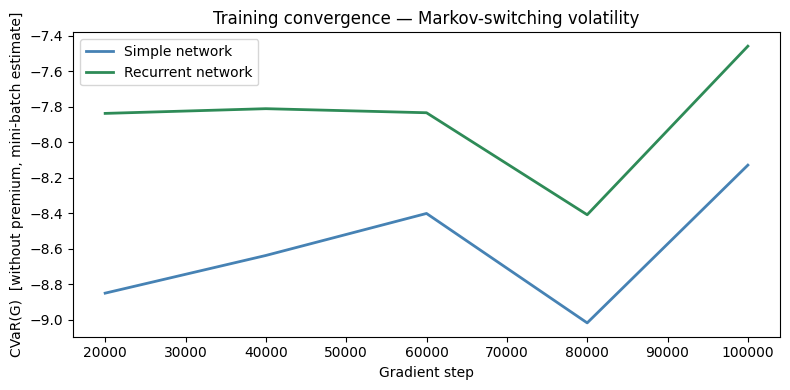

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
iters_s, cvars_s = zip(*hist_simple)
iters_r, cvars_r = zip(*hist_recurrent)
ax.plot(iters_s, cvars_s, color='steelblue', lw=2, label='Simple network')
ax.plot(iters_r, cvars_r, color='seagreen',  lw=2, label='Recurrent network')
ax.set_xlabel('Gradient step')
ax.set_ylabel('CVaR(G)  [without premium, mini-batch estimate]')
ax.set_title('Training convergence — Markov-switching volatility')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Out-of-Sample Evaluation

The **model benchmark** (Markov delta) uses the precomputed lookup tables with the **true regime sequence**. It is an oracle that knows whether the market is in the L or H state at every step. The networks have no such access.

**CVaR score** $= -\mathrm{CVaR}_{0.5}(\tilde{G}^\pi)$ where $\tilde{G}^\pi = G^\pi + \mathcal{C}_M$ (net P&L when charging the Markov model price). A score of zero means the strategy perfectly covers the option; a positive score means additional premium is needed.

In [14]:
S_test_np  = S_test.cpu().numpy()
pay_np     = payoff_test.cpu().numpy()

# ── Network hedge P\&L (regime hidden) ────────────────────────────────────────
with torch.no_grad():
    pnl_s, deltas_s_list = simple_h(S_test)    # cache deltas for plotting
    pnl_r, _             = recurrent_h(S_test)
pnl_s = pnl_s.cpu().numpy()
pnl_r = pnl_r.cpu().numpy()

# ── Model (Markov delta) hedge P\&L — uses true regime sequence ────────────────
print('Computing Markov delta hedge P\u0026L ...')
pnl_m = markov_hedge_pnl(S_test_np, states_test)

# ── Charge model price; compute G\u0303 and CVaR scores ──────────────────────────
G_s = pnl_s - pay_np + model_price
G_r = pnl_r - pay_np + model_price
G_m = pnl_m - pay_np + model_price

score_s = -cvar_np(G_s)
score_r = -cvar_np(G_r)
score_m = -cvar_np(G_m)

print()
print('=' * 68)
print('Results \u2014 CVaR(50%), No Transaction Costs, Markov-Switching Vol')
print('=' * 68)
print(f'Markov model price (stationary initial):  {model_price:.4f}')
print()
hdr = f'{"Strategy":<28}{"CVaR(50%)":>12}{"CVaR score":>12}{"Implied price":>14}'
print(hdr)
print('-' * 68)
for name, G, score in [
    ('Model hedge (Markov \u0394)', G_m, score_m),
    ('Simple network',          G_s, score_s),
    ('Recurrent network',       G_r, score_r),
]:
    cvar = cvar_np(G)
    print(f'{name:<28}{cvar:>12.4f}{score:>12.4f}{model_price+score:>14.4f}')
print('=' * 68)

Computing Markov delta hedge P&L ...

Results — CVaR(50%), No Transaction Costs, Markov-Switching Vol
Markov model price (stationary initial):  5.5780

Strategy                       CVaR(50%)  CVaR score Implied price
--------------------------------------------------------------------
Model hedge (Markov Δ)           -2.1809      2.1809        7.7588
Simple network                   -2.7181      2.7181        8.2961
Recurrent network                -2.2193      2.2193        7.7973


## 7. Plots

- **Left panel**: P&L distributions for all three strategies.
- **Centre panel**: Simple network's expected position $\mathbb{E}[\delta_{15} \mid S_{15},\, \text{regime}]$, separated by the true regime at $t=15$, vs the Markov delta for each state. If the network is successfully inferring the regime, the L-state and H-state conditional curves should approach $\Delta_{M,L}$ and $\Delta_{M,H}$ respectively. If it ignores regime information, both curves will coincide at a single averaged delta.
- **Right panel**: Recurrent network position $\delta_{15} = a_{15} + \delta_{14}$ for fixed $\delta_{14}$ values, vs both Markov deltas. Since the Recurrent network has no direct regime input, we show how its response varies with $\delta_{14}$, which encodes implicit path history.

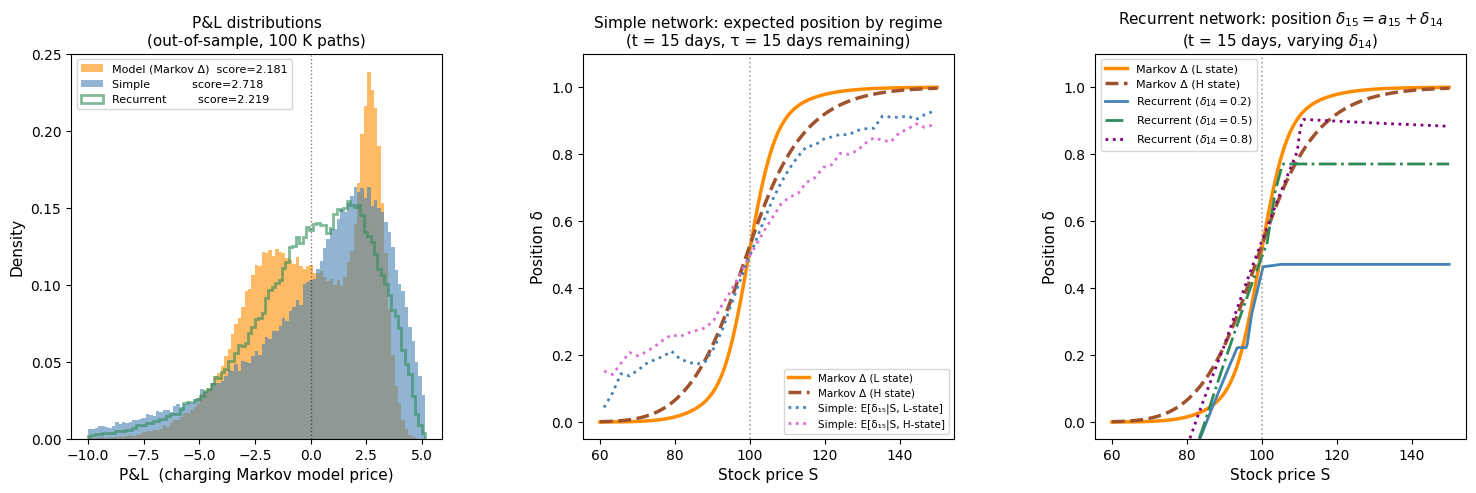

Figure saved → deep_hedging_markov.png


In [16]:
from scipy.stats import binned_statistic

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Panel 1: P\&L distributions ───────────────────────────────────────────────
ax1  = fig.add_subplot(gs[0])
all_G = np.concatenate([G_m, G_s, G_r])
lo    = max(np.percentile(all_G, 0.5) - 0.3, -10)
hi    = min(np.percentile(all_G, 99.5) + 0.3,  10)
bins  = np.linspace(lo, hi, 100)

ax1.hist(G_m, bins=bins, alpha=0.60, color='darkorange', density=True,
         label=f'Model (Markov \u0394)  score={score_m:.3f}')
ax1.hist(G_s, bins=bins, alpha=0.60, color='steelblue',  density=True,
         label=f'Simple            score={score_s:.3f}')
ax1.hist(G_r, bins=bins, alpha=0.60, color='seagreen',   density=True,
         histtype='step', lw=2, label=f'Recurrent         score={score_r:.3f}')
ax1.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
ax1.set_xlabel('P\u0026L  (charging Markov model price)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('P\u0026L distributions\n(out-of-sample, 100 K paths)', fontsize=11)
ax1.legend(fontsize=8)

# ── Panel 2: Simple network — E[\u03b4\u2081\u2085 | S\u2081\u2085, regime] vs Markov delta ─────────────────────
ax2   = fig.add_subplot(gs[1])
T_MID = 15
TAU_M = (N_STEPS - T_MID) * DT
S_grid = np.linspace(60, 150, 300)

mk_delta_L = delta_lut_L[T_MID](S_grid)
mk_delta_H = delta_lut_H[T_MID](S_grid)

pos_15_s = deltas_s_list[T_MID].cpu().numpy()
S_15_arr = S_test[:, T_MID].cpu().numpy()
state_15 = states_test[:, T_MID]

ax2.plot(S_grid, mk_delta_L, color='darkorange', lw=2.5, label='Markov \u0394 (L state)')
ax2.plot(S_grid, mk_delta_H, color='sienna',     lw=2.5, ls='--', label='Markov \u0394 (H state)')

for state_val, net_col, state_lbl in [(0, 'steelblue', 'L'), (1, 'orchid', 'H')]:
    mask = state_15 == state_val
    mean_pos, edges, _ = binned_statistic(
        S_15_arr[mask], pos_15_s[mask], 'mean', bins=40, range=(60, 150)
    )
    centers = 0.5*(edges[:-1]+edges[1:])
    valid   = ~np.isnan(mean_pos)
    ax2.plot(centers[valid], mean_pos[valid], color=net_col, lw=2, ls=':',
             label=f'Simple: E[\u03b4\u2081\u2085|S, {state_lbl}-state]')

ax2.axvline(K, color='grey', ls=':', lw=1.2, alpha=0.7)
ax2.set_xlabel('Stock price S', fontsize=11)
ax2.set_ylabel('Position \u03b4', fontsize=11)
ax2.set_title(f'Simple network: expected position by regime\n'
              f'(t = {T_MID} days, \u03c4 = {N_STEPS-T_MID} days remaining)', fontsize=11)
ax2.legend(fontsize=7.5)
ax2.set_ylim(-0.05, 1.10)

# ── Panel 3: Recurrent network — position \u03b4\u2081\u2085 = a\u2081\u2085 + \u03b4\u2081\u2084 for varying \u03b4\u2081\u2084 ────────────
ax3     = fig.add_subplot(gs[2])
S_torch = torch.tensor(S_grid, dtype=torch.float32, device=DEVICE)

ax3.plot(S_grid, mk_delta_L, color='darkorange', lw=2.5, label='Markov \u0394 (L state)')
ax3.plot(S_grid, mk_delta_H, color='sienna',     lw=2.5, ls='--', label='Markov \u0394 (H state)')

for prev_d_val, color, ls, lbl in [
    (0.2, 'steelblue', '-',  r'Recurrent ($\delta_{14}=0.2$)'),
    (0.5, 'seagreen',  '-.', r'Recurrent ($\delta_{14}=0.5$)'),
    (0.8, 'purple',    ':',  r'Recurrent ($\delta_{14}=0.8$)'),
]:
    prev_d_t = torch.full((len(S_grid),), prev_d_val, device=DEVICE)
    with torch.no_grad():
        x_r = torch.stack([(S_torch/K).log(), prev_d_t], dim=1)
        a_r = recurrent_h.nets[T_MID](x_r).squeeze(1).cpu().numpy()
    net_d_r = a_r + prev_d_val   # position = action + prev position
    ax3.plot(S_grid, net_d_r, color=color, lw=2, ls=ls, label=lbl)

ax3.axvline(K, color='grey', ls=':', lw=1.2, alpha=0.7)
ax3.set_xlabel('Stock price S', fontsize=11)
ax3.set_ylabel('Position \u03b4', fontsize=11)
ax3.set_title(f'Recurrent network: position $\\delta_{{15}} = a_{{15}} + \\delta_{{14}}$\n'
              f'(t = {T_MID} days, varying $\\delta_{{14}}$)', fontsize=11)
ax3.legend(fontsize=8)
ax3.set_ylim(-0.05, 1.10)

plt.savefig('deep_hedging_markov.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved \u2192 deep_hedging_markov.png')

## 8. Discussion

### Comparison table

| | `deep_hedging_section42.ipynb` (BS baseline) | This notebook (Markov) |
|---|---|---|
| Market | $\sigma = 0.20$ (constant) | $\sigma \in \{0.20, 0.70\}$, hidden regime |
| Model benchmark | BS delta $N(d_1)$, no regime needed | Markov delta, requires knowing regime |
| Model CVaR score | ≈ 0.32 | ≈ 2.18 |
| Recurrent CVaR score | ≈ 0.35 | ≈ 2.22 |
| Simple CVaR score | ≈ 0.95 | ≈ 2.72 |

For the model benchmark and the Recurrent network, CVaR scores are roughly 6–7× larger in the Markov setting (0.32 → 2.18, 0.35 → 2.22). The Simple network's score is only about 3× larger (0.95 → 2.72), because its BS-setting performance was already degraded by the action-position information asymmetry. The Markov regime simply adds one more source of difficulty on top. The wider CVaR scores reflect the substantially wider P&L distribution caused by regime-switching: $\sigma_H = 0.70$ creates large, path-dependent hedging errors that cannot be eliminated by stock alone.

### What the plots reveal

**Panel 2 (Simple network by regime).** The two conditional curves $\mathbb{E}[\delta_{15} \mid S_{15},\, \text{L}]$ and $\mathbb{E}[\delta_{15} \mid S_{15},\, \text{H}]$ tell the story of how much the Simple network has learned about the regime:
- If both curves coincide at an intermediate delta, the network is regime-blind. It applies the same average hedge regardless of which state the market is in.
- If they separate and approach $\Delta_{M,L}$ and $\Delta_{M,H}$ respectively, the network is partially inferring the regime from moneyness alone. In the single-factor setting, $\log(S_t/K)$ carries almost no information about past volatility, so significant separation is unlikely.

The catch: $\Delta_{M,H}$ is much flatter than $\Delta_{M,L}$ across the moneyness range. This is because $\sigma_H = 0.70$ spreads the conditional distribution of $S_T$ so widely that the call payoff is nearly equally likely for all near-the-money spot prices. The delta is nearly 0.5 everywhere around the strike.

**Panel 3 (Recurrent network by $\delta_{14}$).** Unlike the BS case, the three position curves are not expected to collapse onto a single line. In the no-cost BS case, the optimal strategy was always to rebalance to $N(d_1)$ regardless of starting position. Here, $\delta_{14}$ carries implicit regime history:
- Paths with low $\delta_{14}$ have, on average, been in a calmer (L-regime) environment. The optimal target delta is $\Delta_{M,L}$, which is steep near the money.
- Paths with high $\delta_{14}$ may reflect aggressive rebalancing in a volatile (H-regime) environment.

If the Recurrent network has learned to use this signal, position curves for different $\delta_{14}$ values should interpolate between $\Delta_{M,L}$ and $\Delta_{M,H}$.

### Performance ordering

Since the model benchmark observes the true regime at each step while the networks do not:

$$\text{CVaR score (Markov}\,\Delta) \;<\; \text{CVaR score (Recurrent)} \;<\; \text{CVaR score (Simple)}$$

The gap between both networks and the model benchmark represents the cost of regime uncertainty which is the irreducible hedging error from not observing the volatility state. The gap between Recurrent and Simple combines the action-position information asymmetry (established in `deep_hedging_section42.ipynb`) with the regime-inference advantage that $\delta_{t-1}$ provides.

Notably, the Recurrent network (CVaR score ≈ 2.22) nearly matches the oracle Markov delta (≈ 2.18) despite never seeing the regime which is a strong result showing that position history is a powerful implicit state signal.